# Setting up an equilibrium disc

In [3]:
import numpy as np
import agama

In [2]:
# ----------------------------
# Units (match AGAMA examples)
# ----------------------------
agama.setUnits(
    length=1, velocity=1, mass=1
)  # kpc, km/s, Msun  :contentReference[oaicite:2]{index=2}

# ----------------------------
# Self-consistent model (SCM) grids
# (taken from AGAMA's SCM.ini, but you can tighten/loosen for speed/accuracy)
# ----------------------------
scm_params = dict(
    rminSph=0.01,
    rmaxSph=5000.0,
    sizeRadialSph=50,
    lmaxAngularSph=4,
    RminCyl=0.2,
    RmaxCyl=50.0,
    sizeRadialCyl=30,
    zminCyl=0.04,
    zmaxCyl=10.0,
    sizeVerticalCyl=30,
    useActionInterpolation=False,
)

disk_scm_component = dict(
    RminCyl=0.1,
    RmaxCyl=30.0,
    sizeRadialCyl=20,
    zminCyl=0.05,
    zmaxCyl=10.0,
    sizeVerticalCyl=16,
)

model = agama.SelfConsistentModel(**scm_params)

# ----------------------------
# 1) Initial "guess" density profiles
# ----------------------------
# A simple exponential/sech^2-like disk density (static at first)
# These parameter names follow the SCM.ini example. :contentReference[oaicite:3]{index=3}
dens_disk_guess = agama.Density(
    type="Disk",
    surfaceDensity=9.0e8,  # in Msun/kpc^2 in the example setup
    scaleRadius=2.4,  # kpc
    scaleHeight=-0.2,  # kpc; negative -> isothermal(sech^2) in the example :contentReference[oaicite:4]{index=4}
)

# A fixed spheroidal halo density (kept static here for simplicity)
dens_halo = agama.Density(
    type="Spheroid",
    densityNorm=2.2e7,  # Msun/kpc^3 at scaleRadius (per example)
    axisRatioZ=1.0,
    gamma=1.0,
    beta=3.0,
    scaleRadius=12.0,  # kpc
    outerCutoffRadius=250.0,  # kpc
)

# Add components (initially density-based)
model.components.append(agama.Component(density=dens_disk_guess, disklike=True))
model.components.append(agama.Component(density=dens_halo, disklike=False))

# Build initial potential from these density components
model.iterate()

# ----------------------------
# 2) Replace the disk with a DF-based quasi-isothermal disc in the current potential
# ----------------------------
df_disk = agama.DistributionFunction(
    type="QuasiIsothermal",
    potential=model.potential,  # important: QI DF needs a potential :contentReference[oaicite:5]{index=5}
    Sigma0=9.3e8,  # Msun/kpc^2
    Rdisk=2.4,  # kpc
    Hdisk=0.10,  # kpc
    sigmar0=50.0,  # km/s
    sigmamin=15.0,  # km/s
    Rsigmar=12.0,  # kpc
    qJr=0.1,
    qJz=0.1,
)

model.components[0] = agama.Component(df=df_disk, disklike=True, **disk_scm_component)

# ----------------------------
# 3) Iterate a few times for self-consistency of the DF-based disk density in the total potential
# ----------------------------
for it in range(5):
    print(f"SCM iteration {it+1}/5")
    model.iterate()

# ----------------------------
# 4) Sample an N-body realisation from the DF in the (now) converged potential
# ----------------------------
N = 25_000
gm = agama.GalaxyModel(
    potential=model.potential, df=df_disk, af=model.af
)  # pattern from examples :contentReference[oaicite:6]{index=6}
posvel, mass = gm.sample(N)  # posvel shape (N,6): x,y,z,vx,vy,vz

# Optionally: recentre / remove net drift (useful if your sampler introduces tiny numerical offsets)
posvel[:, 0:3] -= np.average(posvel[:, 0:3], axis=0, weights=mass)
posvel[:, 3:6] -= np.average(posvel[:, 3:6], axis=0, weights=mass)

# Save to a simple text file
# out = np.column_stack([posvel, mass])
# np.savetxt("agama_disk_ic.txt", out, fmt="%.8e")
# print("Wrote agama_disk_ic.txt with columns: x y z vx vy vz m")

# Save as structured NumPy binary
np.savez("agama_disk_ic.npz", pos=posvel[:, 0:3], vel=posvel[:, 3:6], mass=mass)
print("Saved agama_disk_ic.npz (pos, vel, mass)")

# for large files try the compressed format (smaller file size, but slower read/write):
#np.savez_compressed(
#    "agama_disk_ic.npz", pos=posvel[:, :3], vel=posvel[:, 3:6], mass=mass
#)

# If you want Gadget format instead (often convenient):
# agama.writeSnapshot("agama_disk_ic", (posvel, mass), format="gadget")

Updating potential...done
Updating action finder...done
Computing density for component 0...done
Computing density for component 1...done
Updating potential...done
Updating action finder...done
SCM iteration 1/5
Computing density for component 0...done
Computing density for component 1...done
Updating potential...done
Updating action finder...SCM iteration 2/5done

Computing density for component 0...done
Computing density for component 1...done
Updating potential...done
Updating action finder...SCM iteration 3/5done

Computing density for component 0...done
Computing density for component 1...done
Updating potential...done
Updating action finder...SCM iteration 4/5done

Computing density for component 0...done
Computing density for component 1...done
Updating potential...done
Updating action finder...SCM iteration 5/5done

Computing density for component 0...done
Computing density for component 1...done
Updating potential...done
Updating action finder...done
Saved agama_disk_ic.npz (p

In [4]:
# load the equilibrium disc model initial conditions back in for use in the JAX simulations
data = np.load("agama_disk_ic.npz")
pos = data["pos"]
vel = data["vel"]
mass = data["mass"]

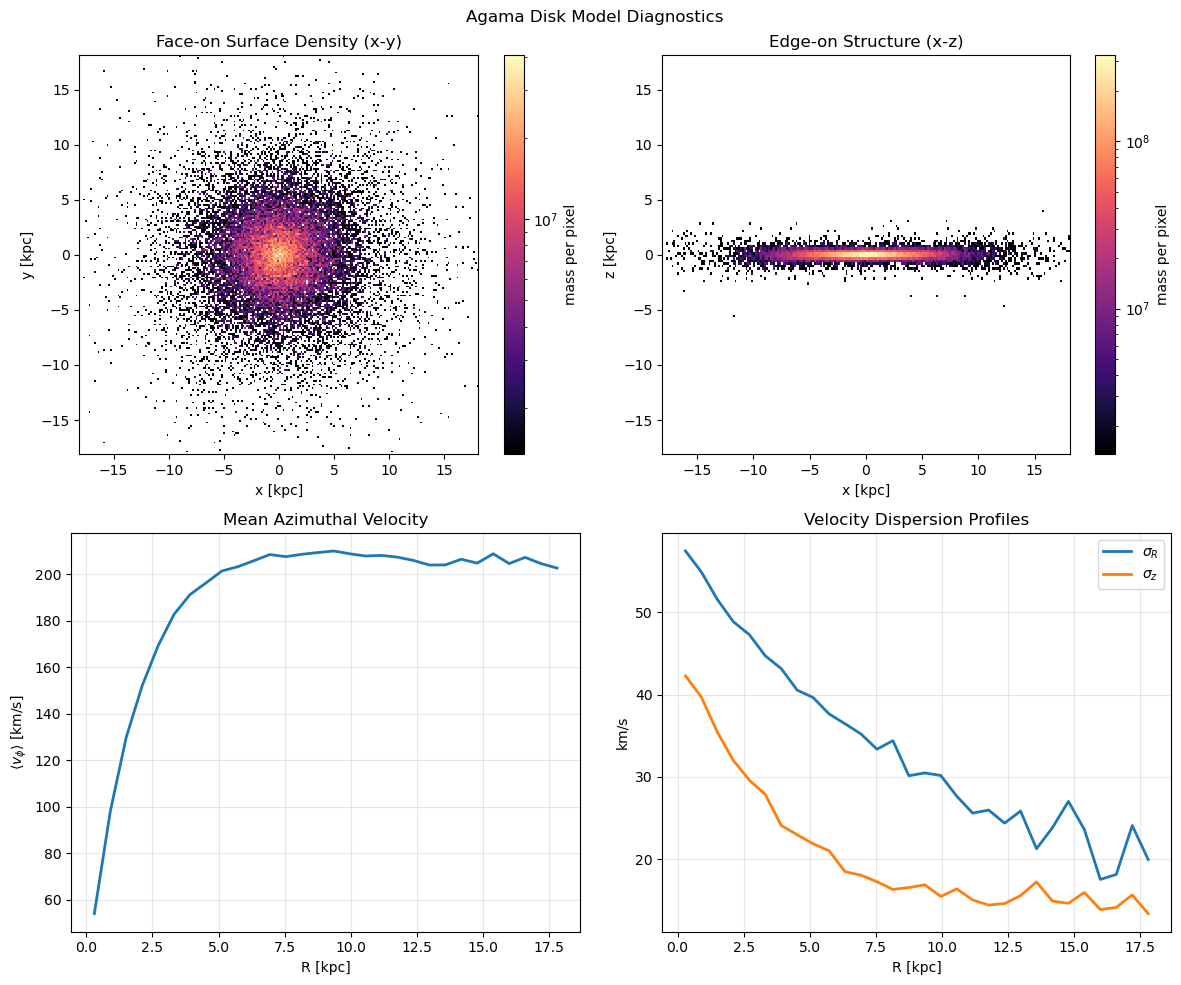

In [8]:
# Visualize sampled Agama disk model (uses posvel, mass from previous cell)
import matplotlib.pyplot as plt

x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]
vx, vy, vz = vel[:, 0], vel[:, 1], vel[:, 2]
R = np.sqrt(x**2 + y**2)

# Cylindrical velocity components
vR = (x * vx + y * vy) / np.maximum(R, 1e-8)
vphi = (x * vy - y * vx) / np.maximum(R, 1e-8)

Rmax = np.percentile(R, 99.5)
zmax = np.percentile(np.abs(z), 99.5)

# Weighted radial profiles
nbins = 30
edges = np.linspace(0.0, Rmax, nbins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
inds = np.digitize(R, edges) - 1

mean_vphi = np.full(nbins, np.nan)
sig_vR = np.full(nbins, np.nan)
sig_vz = np.full(nbins, np.nan)

for i in range(nbins):
    m = inds == i
    if np.any(m):
        w = mass[m]
        mean_vphi[i] = np.average(vphi[m], weights=w)
        mu_vR = np.average(vR[m], weights=w)
        mu_vz = np.average(vz[m], weights=w)
        sig_vR[i] = np.sqrt(np.average((vR[m] - mu_vR)**2, weights=w))
        sig_vz[i] = np.sqrt(np.average((vz[m] - mu_vz)**2, weights=w))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Face-on mass map
h1 = ax[0, 0].hist2d(
    x, y, bins=220,
    range=[[-Rmax, Rmax], [-Rmax, Rmax]],
    weights=mass,
    norm='log',
    cmap='magma'
)
ax[0, 0].set_title('Face-on Surface Density (x-y)')
ax[0, 0].set_xlabel('x [kpc]')
ax[0, 0].set_ylabel('y [kpc]')
ax[0, 0].set_aspect('equal')
plt.colorbar(h1[3], ax=ax[0, 0], label='mass per pixel')

# Edge-on mass map
h2 = ax[0, 1].hist2d(
    x, z, bins=[220, 160],
    range=[[-Rmax, Rmax], [-Rmax, Rmax]],
    weights=mass,
    norm='log',
    cmap='magma'
)
ax[0, 1].set_title('Edge-on Structure (x-z)')
ax[0, 1].set_xlabel('x [kpc]')
ax[0, 1].set_ylabel('z [kpc]')
plt.colorbar(h2[3], ax=ax[0, 1], label='mass per pixel')

# Mean rotation curve
ax[1, 0].plot(centers, mean_vphi, lw=2)
ax[1, 0].set_title('Mean Azimuthal Velocity')
ax[1, 0].set_xlabel('R [kpc]')
ax[1, 0].set_ylabel(r'$\langle v_\phi \rangle$ [km/s]')
ax[1, 0].grid(alpha=0.3)

# Velocity dispersions
ax[1, 1].plot(centers, sig_vR, lw=2, label=r'$\sigma_R$')
ax[1, 1].plot(centers, sig_vz, lw=2, label=r'$\sigma_z$')
ax[1, 1].set_title('Velocity Dispersion Profiles')
ax[1, 1].set_xlabel('R [kpc]')
ax[1, 1].set_ylabel('km/s')
ax[1, 1].grid(alpha=0.3)
ax[1, 1].legend()

fig.suptitle('Agama Disk Model Diagnostics', y=0.98)
fig.tight_layout()
plt.show()
